In [17]:
import pandas as pd

def processingdata():
    df = pd.read_csv("healthcare-dataset-stroke-data.csv")
    dictn = {}
    cols = df.select_dtypes(include=["object"]).columns

    for col in df.columns:
        if col in cols:
            df[col] = df[col].fillna(df[col].mode()[0])
            uni_vals = df[col].unique()
            mpp = {val: i for i, val in enumerate(uni_vals)}
            df[col] = df[col].map(mpp)
            dictn[col] = mpp
        else:
            df[col] = pd.to_numeric(df[col], errors="coerce")
            df[col] = df[col].fillna(df[col].mean())
    return df, dictn

df, dictn = processingdata()
print(df.head())
print(dictn)

      id  gender   age  hypertension  heart_disease  ever_married  work_type  \
0   9046       0  67.0             0              1             0          0   
1  51676       1  61.0             0              0             0          1   
2  31112       0  80.0             0              1             0          0   
3  60182       1  49.0             0              0             0          0   
4   1665       1  79.0             1              0             0          1   

   Residence_type  avg_glucose_level        bmi  smoking_status  stroke  
0               0             228.69  36.600000               0       1  
1               1             202.21  28.893237               1       1  
2               1             105.92  32.500000               1       1  
3               0             171.23  34.400000               2       1  
4               1             174.12  24.000000               1       1  
{'gender': {'Male': 0, 'Female': 1, 'Other': 2}, 'ever_married': {'Yes': 0,

In [18]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(df.drop('stroke', axis=1), df['stroke'], test_size=0.2, random_state=42)

# Class-weighted logistic model
model = LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

# Metrics
print("📊 Logistic Regression BEFORE PCA")
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))


📊 Logistic Regression BEFORE PCA
Accuracy: 0.7270058708414873
              precision    recall  f1-score   support

           0       0.98      0.72      0.83       960
           1       0.16      0.82      0.27        62

    accuracy                           0.73      1022
   macro avg       0.57      0.77      0.55      1022
weighted avg       0.93      0.73      0.80      1022



c:\Users\ysing\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


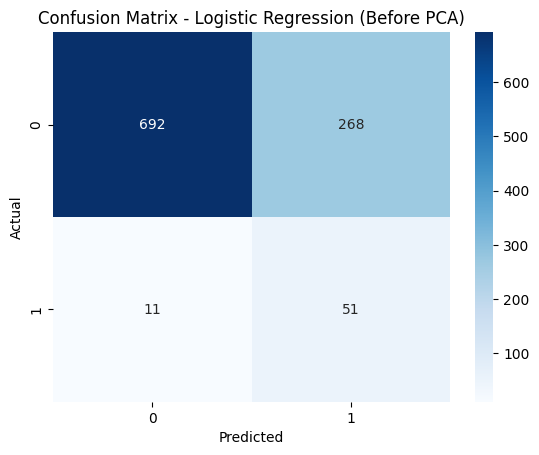

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - Logistic Regression (Before PCA)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


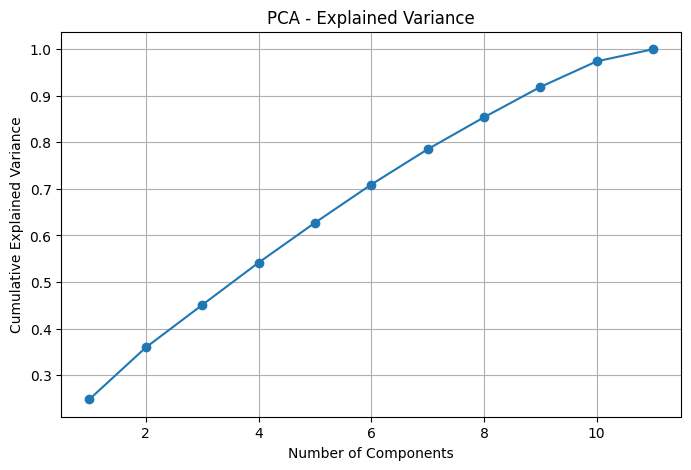

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

X = df.drop(columns=['stroke'])  # Drop target
y = df['stroke']  # Save the target separately

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA()
X_pca = pca.fit_transform(X_scaled)

# Plot cumulative explained variance
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(pca.explained_variance_ratio_)+1), 
         pca.explained_variance_ratio_.cumsum(), marker='o')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('PCA - Explained Variance')
plt.grid(True)
plt.show()

In [4]:
pca_final = PCA(n_components=9)
X_pca_final = pca_final.fit_transform(X_scaled)

pca_df = pd.DataFrame(X_pca_final, columns=[f'PC{i+1}' for i in range(9)])
pca_df['stroke'] = y.values  # add target back if needed
pca_df.head()


,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,stroke
0,3.221169,3.283013,-1.537321,-0.297079,-1.297812,1.530022,1.783939,-0.945765,1.528919,1
1,1.245522,0.200973,1.128576,-0.067240,1.079238,0.309756,1.481981,-0.945867,-1.053727,1
2,2.426868,2.284803,0.573813,-0.461361,-2.074210,2.544963,-0.012649,0.580955,1.213932,1
3,1.108826,-0.366884,-0.254789,1.340682,0.859843,-0.172847,1.589078,0.337454,-0.355587,1
4,2.044716,1.247470,-0.160299,-2.110058,2.373079,-0.219169,-1.365524,-0.628045,-1.073827,1


In [16]:
# Applying Logistic Regression

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(pca_df.drop('stroke', axis=1), pca_df['stroke'], test_size=0.2, random_state=42)

# Train the model
model = LogisticRegression(class_weight='balanced')
model.fit(X_train, y_train)

# Predict and evaluate
y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
report = classification_report(y_test, y_pred, target_names=["No Stroke", "Stroke"])
print(report)

Accuracy: 0.6976516634050881
              precision    recall  f1-score   support

   No Stroke       0.99      0.69      0.81       960
      Stroke       0.15      0.84      0.25        62

    accuracy                           0.70      1022
   macro avg       0.57      0.76      0.53      1022
weighted avg       0.93      0.70      0.78      1022



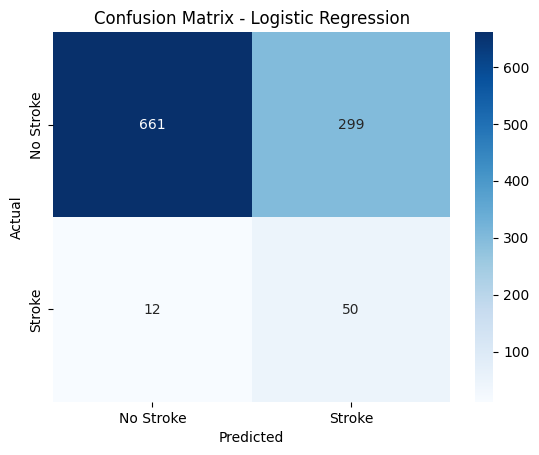

In [15]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=["No Stroke", "Stroke"], yticklabels=["No Stroke", "Stroke"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Logistic Regression")
plt.show()